# Chapter 2. Lie Groups and Lie Algebras

**Source Span.** Helgason, *Differential Geometry, Lie Groups, and Symmetric Spaces*, Chapter II, printed pages 98-154 (approximately PDF pages 125-181).

This notebook rebuilds Chapter II as a standalone computational lesson. The chapter connects local analytic group laws to infinitesimal brackets, then uses that bridge to study subgroups, homogeneous spaces, adjoint groups, semisimple compactness, and invariant differential forms. The notebook avoids copied theorem prose and instead gives small models where the same mechanisms can be inspected directly.

The guiding question is: how much of a Lie group is already visible in its tangent space at the identity, and where do global topology and closedness add extra information?


## Visual Storyboard and Coverage Plan

The chapter is not just a list of definitions. It is a chain of bridges: local group law to bracket, bracket to exponential, exponential to subgroups, subgroups to cosets and actions, adjoint action to semisimplicity, and invariant forms back to structure constants.

- Exponential map and one-parameter subgroups: use the orientation-preserving Euclidean motion group `SE(2)` to show analytic group law, one-parameter motion, and the local exponential formula.
- Universal enveloping algebra: use the Heisenberg Lie algebra to display PBW normal ordering and the way commutator relations rewrite words.
- Lie subgroups and closedness: use an irrational winding on a torus to show why an analytic subgroup can fail to be closed in the ambient torus.
- Coset spaces and homogeneous spaces: use `SO(3)/SO(2) = S^2` as a concrete orbit-stabilizer model with a local cross-section.
- Adjoint group: use the `sl(2)` basis to show `Ad(exp(tH))` scaling root directions and to check `Ad(exp X)=exp(ad X)`.
- Semisimple and compact Lie algebras: compare Killing-form signatures for `sl(2,R)` and compact `su(2)`.
- Invariant forms: use the Heisenberg group Maurer-Cartan equations as a direct left-invariant form calculation.

**Library Routing.** NumPy handles finite matrix and sampling experiments, SymPy checks symbolic brackets/forms, Matplotlib draws the geometric models, and the course artifact helpers save local PNG/CSV/JSON evidence under the Chapter 2 artifact subtree.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - activates 3D projection
import numpy as np
import sympy as sp

_here = Path.cwd().resolve()
for candidate in [_here, *_here.parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the Helgason book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (  # noqa: E402
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-02-lie-groups-and-lie-algebras"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

artifact_paths: list[Path] = []
chapter_checks: dict[str, bool | float | str] = {}

def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()

def record(path: Path) -> Path:
    artifact_paths.append(Path(path))
    return Path(path)


In [2]:
storyboard = [
    {"source_sections": "1. Exponential mapping", "witness": "SE(2) one-parameter subgroup and exponential formula", "artifact": "figures/se2_exponential_motion.png", "validation": "homomorphism law and matrix determinant checks"},
    {"source_sections": "1. Universal enveloping algebra", "witness": "Heisenberg PBW normal ordering table", "artifact": "tables/heisenberg_pbw_rewrite_table.csv", "validation": "rewrites preserve central commutator relation"},
    {"source_sections": "2. Lie subgroups and subalgebras", "witness": "irrational torus winding and closure diagnostics", "artifact": "figures/torus_irrational_winding.png", "validation": "many occupied bins and nonperiodic endpoint"},
    {"source_sections": "3-4. Transformation groups and cosets", "witness": "SO(3)/SO(2) orbit-stabilizer sphere model", "artifact": "figures/so3_so2_coset_sphere.png", "validation": "orbit points remain on sphere and stabilizer fixes north pole"},
    {"source_sections": "5. Adjoint group", "witness": "sl2 adjoint scaling under exp(tH)", "artifact": "figures/sl2_adjoint_scaling.png", "validation": "Ad(exp(tH)) matches exp(t ad_H)"},
    {"source_sections": "6. Semisimple Lie groups", "witness": "Killing form signature comparison for sl2R and su2", "artifact": "tables/killing_form_signature_comparison.csv", "validation": "sl2R indefinite, su2 negative definite"},
    {"source_sections": "7. Invariant forms", "witness": "Heisenberg Maurer-Cartan equations", "artifact": "checks/heisenberg_maurer_cartan_checks.json", "validation": "d omega3 = - omega1 wedge omega2 and d^2=0"},
    {"source_sections": "8 and exercises", "witness": "coverage ledger for no-small-subgroups, exponential failures, closed subgroups, invariant forms", "artifact": "tables/chapter_02_coverage_map.csv", "validation": "every major source block is routed to a section or ledger item"},
]

coverage_rows = [
    {"source_part": "Definition and examples of Lie groups", "captured_as": "SE(2) matrix model, analytic group law, one-parameter motion", "notebook_section": "SE(2) exponential"},
    {"source_part": "Lie algebra and adjoint representation", "captured_as": "matrix brackets, sl2 adjoint action, Ad-exp identity", "notebook_section": "Adjoint action"},
    {"source_part": "Universal enveloping algebra", "captured_as": "Heisenberg PBW normal-order rewrite ledger", "notebook_section": "PBW and enveloping algebra"},
    {"source_part": "Differential of exp and local group law", "captured_as": "exponential homomorphism check and BCH/local behavior note", "notebook_section": "SE(2) exponential and adjoint action"},
    {"source_part": "Lie subgroups and subalgebras", "captured_as": "torus irrational winding, closedness/topological subgroup warning", "notebook_section": "Subgroups and closedness"},
    {"source_part": "Transformation groups", "captured_as": "orbit, isotropy, and induced vector field interpretation", "notebook_section": "Cosets and homogeneous spaces"},
    {"source_part": "Coset spaces", "captured_as": "SO(3)/SO(2) local cross-section model for S2", "notebook_section": "Cosets and homogeneous spaces"},
    {"source_part": "Semisimple and compact Lie groups", "captured_as": "Killing form signature table and compactness criterion", "notebook_section": "Killing form"},
    {"source_part": "Invariant differential forms", "captured_as": "Maurer-Cartan equations for Heisenberg forms", "notebook_section": "Invariant forms"},
    {"source_part": "Perspectives and exercises", "captured_as": "coverage ledger for no-small-subgroups, exponential non-surjectivity, closed subgroups, invariant forms", "notebook_section": "Coverage ledger and takeaways"},
]

storyboard_path = record(save_json(storyboard, CHECKS / "chapter_02_visual_storyboard.json"))
coverage_path = record(save_csv(coverage_rows, TABLES / "chapter_02_coverage_map.csv"))
print(json.dumps({"storyboard_items": len(storyboard), "coverage_rows": len(coverage_rows), "storyboard": rel(storyboard_path), "coverage": rel(coverage_path)}, indent=2))
display_artifact(coverage_path)


{
  "storyboard_items": 8,
  "coverage_rows": 10,
  "storyboard": "artifacts/chapter-02-lie-groups-and-lie-algebras/checks/chapter_02_visual_storyboard.json",
  "coverage": "artifacts/chapter-02-lie-groups-and-lie-algebras/tables/chapter_02_coverage_map.csv"
}


[chapter_02_coverage_map.csv](artifacts/chapter-02-lie-groups-and-lie-algebras/tables/chapter_02_coverage_map.csv)

## 1. The Exponential Map in `SE(2)`

Helgason opens the chapter with Lie groups as analytic groups and uses the orientation-preserving Euclidean motions as a motivating example. A motion is encoded by a rotation angle and a translation vector. The Lie algebra element `(omega, vx, vy)` generates a one-parameter subgroup: for each time `t`, the matrix is a rigid motion with determinant one in the rotation block.

This visual shows the orbit of several points under one such subgroup. The sanity check verifies the homomorphism property `exp((s+t)X)=exp(sX)exp(tX)` numerically and checks that the rotation block remains in `SO(2)`.


{
  "figure": "artifacts/chapter-02-lie-groups-and-lie-algebras/figures/se2_exponential_motion.png",
  "checks": "artifacts/chapter-02-lie-groups-and-lie-algebras/checks/se2_exponential_checks.json",
  "homomorphism_error": 5.551115123125783e-16
}


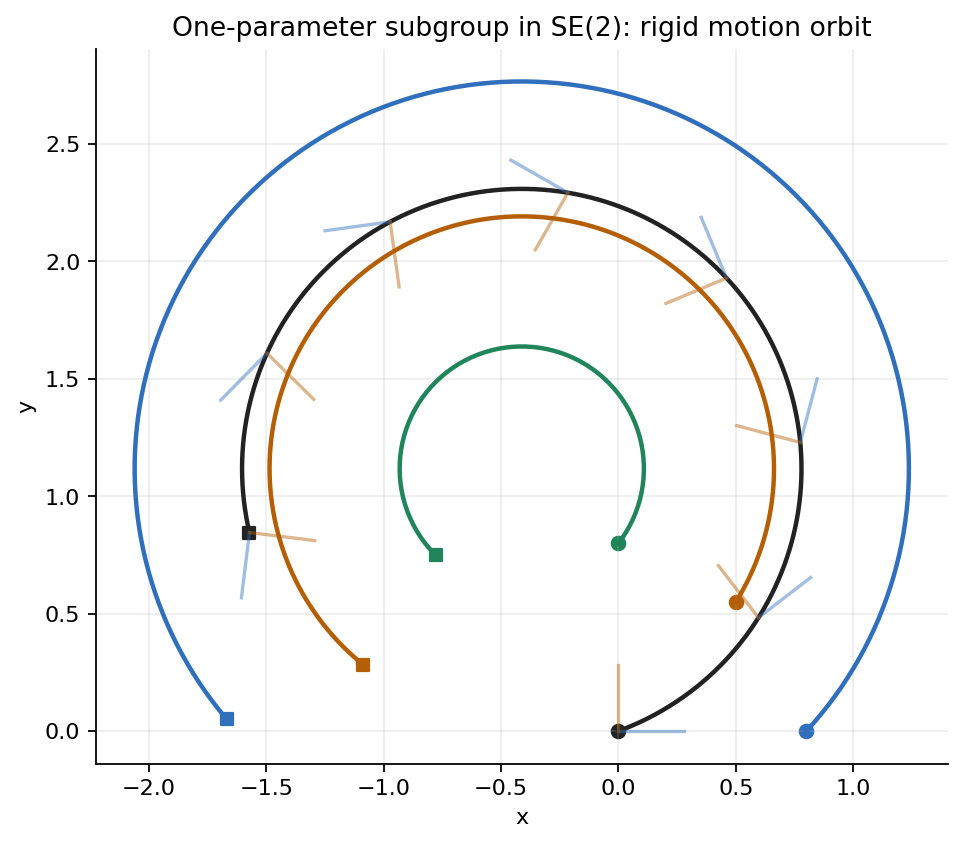

In [3]:
def se2_exp(t: float, omega: float, vx: float, vy: float) -> np.ndarray:
    if abs(omega) < 1e-12:
        R = np.eye(2)
        trans = np.array([vx * t, vy * t], dtype=float)
    else:
        angle = omega * t
        c, s = math.cos(angle), math.sin(angle)
        R = np.array([[c, -s], [s, c]], dtype=float)
        V = np.array([[math.sin(angle) / omega, -(1 - math.cos(angle)) / omega],
                      [(1 - math.cos(angle)) / omega, math.sin(angle) / omega]], dtype=float)
        trans = V @ np.array([vx, vy], dtype=float)
    M = np.eye(3)
    M[:2, :2] = R
    M[:2, 2] = trans
    return M

omega, vx, vy = 0.85, 0.95, 0.35
times = np.linspace(0, 5.4, 160)
seed_points = np.array([[0.0, 0.0, 1.0], [0.8, 0.0, 1.0], [0.0, 0.8, 1.0], [0.5, 0.55, 1.0]])
orbits = []
for point in seed_points:
    orbits.append(np.array([(se2_exp(float(t), omega, vx, vy) @ point)[:2] for t in times]))

fig, ax = plt.subplots(figsize=(8.7, 5.8))
colors = ["#222222", "#2f6fbb", "#20855a", "#b45f06"]
for orbit, color in zip(orbits, colors):
    ax.plot(orbit[:, 0], orbit[:, 1], color=color, linewidth=2.0)
    ax.scatter([orbit[0, 0]], [orbit[0, 1]], color=color, s=36)
    ax.scatter([orbit[-1, 0]], [orbit[-1, 1]], color=color, s=26, marker="s")
for t in np.linspace(0, 5.4, 8):
    M = se2_exp(float(t), omega, vx, vy)
    origin = M[:2, 2]
    x_axis = origin + 0.28 * M[:2, 0]
    y_axis = origin + 0.28 * M[:2, 1]
    ax.plot([origin[0], x_axis[0]], [origin[1], x_axis[1]], color="#2f6fbb", alpha=0.45)
    ax.plot([origin[0], y_axis[0]], [origin[1], y_axis[1]], color="#b45f06", alpha=0.45)
ax.set_aspect("equal")
ax.set_title("One-parameter subgroup in SE(2): rigid motion orbit")
ax.set_xlabel("x")
ax.set_ylabel("y")
se2_figure = record(save_matplotlib(fig, FIGURES / "se2_exponential_motion.png"))
plt.close(fig)

s_probe, t_probe = 1.3, 2.1
lhs = se2_exp(s_probe + t_probe, omega, vx, vy)
rhs = se2_exp(s_probe, omega, vx, vy) @ se2_exp(t_probe, omega, vx, vy)
hom_error = float(np.linalg.norm(lhs - rhs))
rot_det_errors = [abs(float(np.linalg.det(se2_exp(float(t), omega, vx, vy)[:2, :2])) - 1.0) for t in np.linspace(0, 5, 20)]
se2_report = record(save_json({
    "generator": {"omega": omega, "vx": vx, "vy": vy},
    "homomorphism_error": hom_error,
    "max_rotation_determinant_error": float(max(rot_det_errors)),
    "checks": {
        "one_parameter_subgroup_law_holds": hom_error < 1e-12,
        "rotation_block_stays_in_SO2": max(rot_det_errors) < 1e-12,
    },
}, CHECKS / "se2_exponential_checks.json"))
chapter_checks["se2_one_parameter_subgroup_law_holds"] = bool(hom_error < 1e-12)
chapter_checks["se2_rotation_block_stays_in_so2"] = bool(max(rot_det_errors) < 1e-12)
print(json.dumps({"figure": rel(se2_figure), "checks": rel(se2_report), "homomorphism_error": hom_error}, indent=2))
display_artifact(se2_figure)


## 2. Universal Enveloping Algebra and PBW Normal Order

The universal enveloping algebra turns the nonassociative bracket into an associative algebra subject to the rule `XY - YX = [X,Y]`. The point is not that all products commute; it is that products can be rewritten into a controlled normal order. For the Heisenberg Lie algebra with `[X,Y]=Z` and `Z` central, the relation `Y X = X Y - Z` is enough to sort words into PBW-style monomials.

The table below rewrites several short words. It is a finite model of the chapter's PBW discussion: structure constants become rewrite rules, and normal forms keep track of the Lie algebra inside an associative algebra.


In [4]:
order = {"X": 0, "Y": 1, "Z": 2}

def pbw_terms_for_word(word: tuple[str, ...]) -> dict[tuple[str, ...], int]:
    terms = {tuple(word): 1}
    changed = True
    while changed:
        changed = False
        next_terms: dict[tuple[str, ...], int] = {}
        for current, coeff in terms.items():
            applied = False
            for i in range(len(current) - 1):
                pair = current[i], current[i + 1]
                if pair == ("Y", "X"):
                    swapped = current[:i] + ("X", "Y") + current[i + 2:]
                    central = current[:i] + ("Z",) + current[i + 2:]
                    next_terms[swapped] = next_terms.get(swapped, 0) + coeff
                    next_terms[central] = next_terms.get(central, 0) - coeff
                    changed = True
                    applied = True
                    break
                if order[pair[0]] > order[pair[1]]:
                    swapped = current[:i] + (pair[1], pair[0]) + current[i + 2:]
                    next_terms[swapped] = next_terms.get(swapped, 0) + coeff
                    changed = True
                    applied = True
                    break
            if not applied:
                next_terms[current] = next_terms.get(current, 0) + coeff
        terms = {k: v for k, v in next_terms.items() if v != 0}
    return terms

def format_terms(terms: dict[tuple[str, ...], int]) -> str:
    parts = []
    for word, coeff in sorted(terms.items(), key=lambda item: item[0]):
        monomial = "".join(word) if word else "1"
        parts.append(f"{coeff}*{monomial}")
    return " + ".join(parts).replace("+ -", "- ")

words = [tuple("YX"), tuple("YYX"), tuple("YXX"), tuple("ZYX"), tuple("YZX")]
pbw_rows = []
for word in words:
    terms = pbw_terms_for_word(word)
    pbw_rows.append({"word": "".join(word), "normal_form": format_terms(terms), "term_count": len(terms)})
pbw_table = record(save_csv(pbw_rows, TABLES / "heisenberg_pbw_rewrite_table.csv"))

yx = pbw_terms_for_word(tuple("YX"))
xy_minus_z = {("X", "Y"): 1, ("Z",): -1}
pbw_report = record(save_json({
    "relation": "YX = XY - Z for [X,Y]=Z",
    "rewrite_rows": pbw_rows,
    "checks": {
        "yx_rewrites_to_xy_minus_z": yx == xy_minus_z,
        "all_terms_are_normal_ordered": all(all(order[w[i]] <= order[w[i + 1]] for i in range(len(w) - 1)) for terms in [pbw_terms_for_word(w) for w in words] for w in terms),
    },
}, CHECKS / "heisenberg_pbw_checks.json"))
chapter_checks["pbw_yx_rewrite_matches_heisenberg_relation"] = bool(yx == xy_minus_z)
chapter_checks["pbw_outputs_are_normal_ordered"] = bool(all(all(order[w[i]] <= order[w[i + 1]] for i in range(len(w) - 1)) for terms in [pbw_terms_for_word(w) for w in words] for w in terms))
print(json.dumps({"table": rel(pbw_table), "checks": rel(pbw_report)}, indent=2))
display_artifact(pbw_table)


{
  "table": "artifacts/chapter-02-lie-groups-and-lie-algebras/tables/heisenberg_pbw_rewrite_table.csv",
  "checks": "artifacts/chapter-02-lie-groups-and-lie-algebras/checks/heisenberg_pbw_checks.json"
}


[heisenberg_pbw_rewrite_table.csv](artifacts/chapter-02-lie-groups-and-lie-algebras/tables/heisenberg_pbw_rewrite_table.csv)

## 3. Subgroups, Subalgebras, and Closedness

The Lie-subgroup theorem says subalgebras integrate to connected Lie subgroups, but the resulting subgroup need not be closed as a subset of the ambient group. A one-parameter subgroup of the torus with irrational slope is the standard warning: as an abstract Lie group it is a copy of the line modulo its kernel, yet its image winds densely through the torus.

The plot samples the subgroup `t -> (t mod 1, alpha t mod 1)` on the square model of `S^1 x S^1`. The diagnostic counts occupied bins. A high bin count for a one-dimensional parametrized image is a computational hint of dense winding, not a proof, but it makes the closedness issue visible.


{
  "figure": "artifacts/chapter-02-lie-groups-and-lie-algebras/figures/torus_irrational_winding.png",
  "checks": "artifacts/chapter-02-lie-groups-and-lie-algebras/checks/torus_winding_closedness_checks.json",
  "occupied_ratio": 0.986328125
}


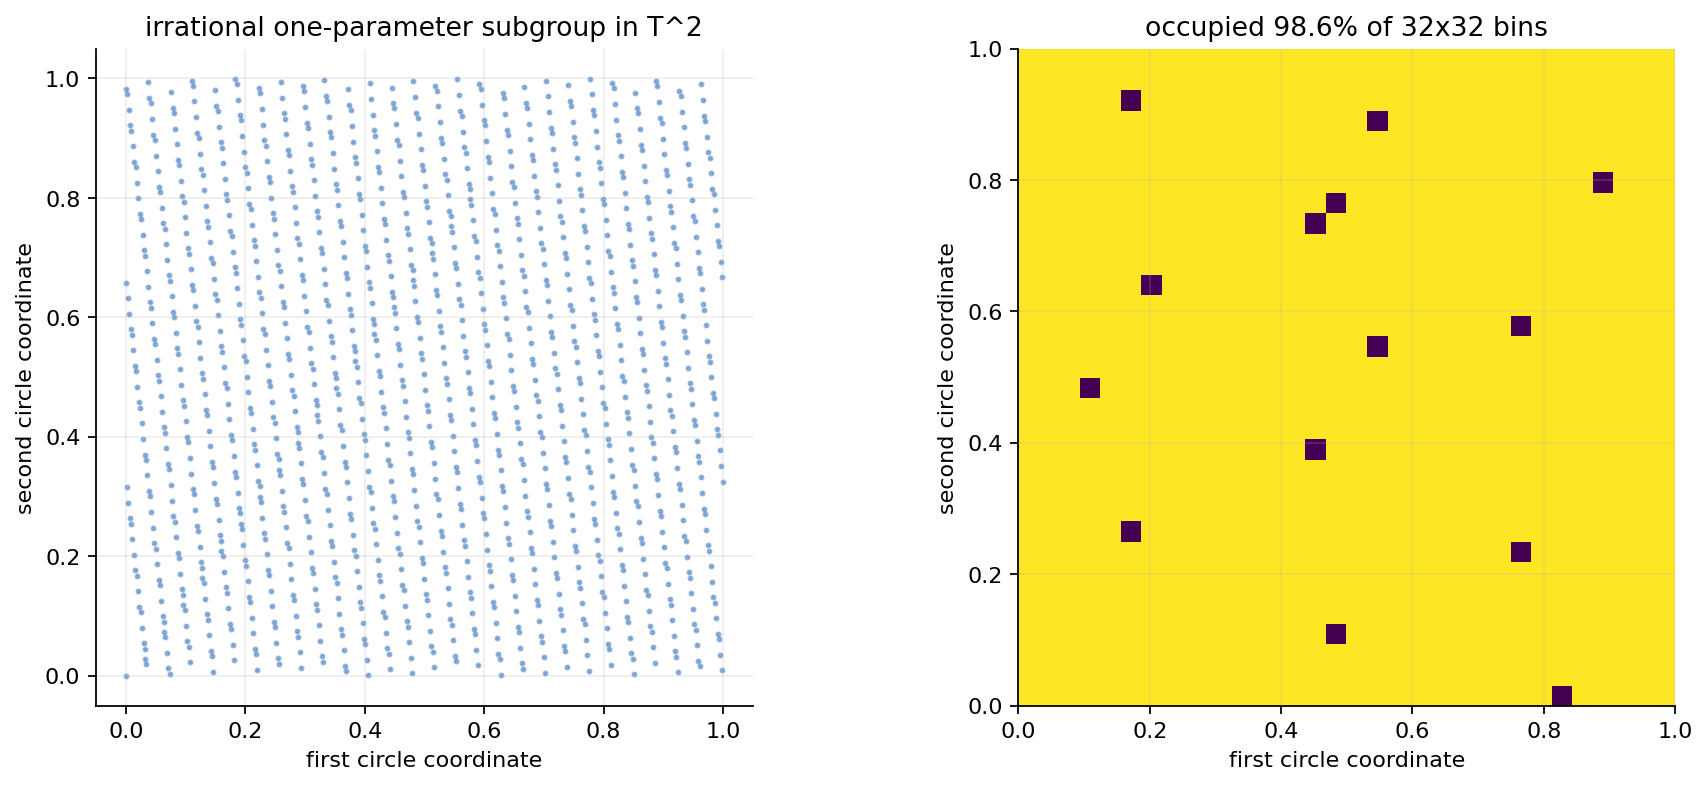

In [5]:
alpha = math.sqrt(2)
t_values = np.linspace(0, 160, 5000)
torus_points = np.column_stack([np.mod(t_values, 1.0), np.mod(alpha * t_values, 1.0)])
bins = 32
occupied = np.zeros((bins, bins), dtype=bool)
indices = np.floor(torus_points * bins).astype(int)
indices = np.clip(indices, 0, bins - 1)
occupied[indices[:, 0], indices[:, 1]] = True
occupied_ratio = float(occupied.mean())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), constrained_layout=True)
axes[0].scatter(torus_points[:1300, 0], torus_points[:1300, 1], s=3, color="#2f6fbb", alpha=0.45)
axes[0].set_title("irrational one-parameter subgroup in T^2")
axes[0].set_xlabel("first circle coordinate")
axes[0].set_ylabel("second circle coordinate")
axes[0].set_aspect("equal")
axes[1].imshow(occupied.T, origin="lower", cmap="viridis", extent=[0, 1, 0, 1], aspect="equal")
axes[1].set_title(f"occupied {occupied_ratio:.1%} of {bins}x{bins} bins")
axes[1].set_xlabel("first circle coordinate")
axes[1].set_ylabel("second circle coordinate")
torus_figure = record(save_matplotlib(fig, FIGURES / "torus_irrational_winding.png"))
plt.close(fig)

endpoint_distance = float(np.linalg.norm(torus_points[-1] - torus_points[0]))
torus_report = record(save_json({
    "slope_alpha": alpha,
    "sample_count": int(len(torus_points)),
    "bin_grid": bins,
    "occupied_ratio": occupied_ratio,
    "endpoint_distance_after_last_sample": endpoint_distance,
    "checks": {
        "occupies_many_bins": occupied_ratio > 0.90,
        "sample_is_not_periodic_at_endpoint": endpoint_distance > 1e-3,
    },
}, CHECKS / "torus_winding_closedness_checks.json"))
chapter_checks["torus_irrational_winding_occupies_many_bins"] = bool(occupied_ratio > 0.90)
chapter_checks["torus_sample_not_periodic_at_endpoint"] = bool(endpoint_distance > 1e-3)
print(json.dumps({"figure": rel(torus_figure), "checks": rel(torus_report), "occupied_ratio": occupied_ratio}, indent=2))
display_artifact(torus_figure)


## 4. Coset Spaces and Homogeneous Spaces

The chapter turns a transitive group action into a coset space: if `G` acts transitively on `M` and `H` fixes a point, then `M` is modeled by `G/H` under suitable hypotheses. The familiar model `SO(3)/SO(2) = S^2` is ideal for inspection. The stabilizer `SO(2)` fixes the north pole, and every coset sends the north pole to a point on the sphere.

The diagram samples rotations that move the north pole around the sphere and overlays a local cross-section coming from a small patch in the tangent plane.


{
  "figure": "artifacts/chapter-02-lie-groups-and-lie-algebras/figures/so3_so2_coset_sphere.png",
  "checks": "artifacts/chapter-02-lie-groups-and-lie-algebras/checks/so3_so2_coset_checks.json"
}


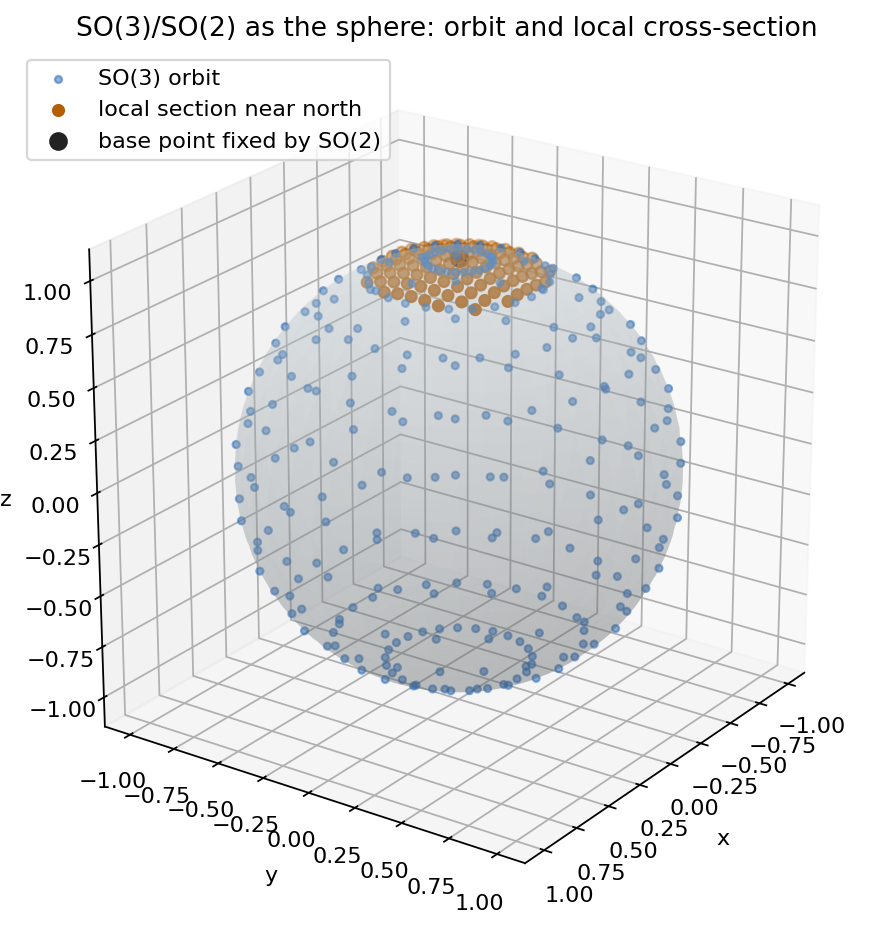

In [6]:
def rotation_y(angle: float) -> np.ndarray:
    c, s = math.cos(angle), math.sin(angle)
    return np.array([[c, 0, s], [0, 1, 0], [-s, 0, c]], dtype=float)

def rotation_z(angle: float) -> np.ndarray:
    c, s = math.cos(angle), math.sin(angle)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=float)

north = np.array([0.0, 0.0, 1.0])
theta = np.linspace(0, math.pi, 42)
phi = np.linspace(0, 2 * math.pi, 84)
Theta, Phi = np.meshgrid(theta, phi)
Xs = np.sin(Theta) * np.cos(Phi)
Ys = np.sin(Theta) * np.sin(Phi)
Zs = np.cos(Theta)

orbit_points = []
for a in np.linspace(0.15, 2.8, 11):
    for b in np.linspace(0, 2 * math.pi, 25, endpoint=False):
        orbit_points.append(rotation_z(float(b)) @ rotation_y(float(a)) @ north)
orbit_points = np.array(orbit_points)
stabilizer_errors = [np.linalg.norm(rotation_z(float(a)) @ north - north) for a in np.linspace(0, 2 * math.pi, 20)]

patch_u = np.linspace(-0.36, 0.36, 11)
patch = []
for u0 in patch_u:
    for v0 in patch_u:
        r2 = u0**2 + v0**2
        if r2 < 0.17:
            patch.append(np.array([u0, v0, math.sqrt(1 - r2)]))
patch = np.array(patch)

fig = plt.figure(figsize=(8.8, 7.0))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(Xs, Ys, Zs, color="#d9e7ef", alpha=0.22, linewidth=0, shade=True)
ax.scatter(orbit_points[:, 0], orbit_points[:, 1], orbit_points[:, 2], s=10, color="#2f6fbb", alpha=0.55, label="SO(3) orbit")
ax.scatter(patch[:, 0], patch[:, 1], patch[:, 2], s=24, color="#b45f06", label="local section near north")
ax.scatter([0], [0], [1], s=55, color="#222222", label="base point fixed by SO(2)")
ax.set_title("SO(3)/SO(2) as the sphere: orbit and local cross-section")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=23, azim=35)
ax.legend(loc="upper left")
coset_figure = record(save_matplotlib(fig, FIGURES / "so3_so2_coset_sphere.png"))
plt.close(fig)

orbit_norm_error = float(np.max(np.abs(np.linalg.norm(orbit_points, axis=1) - 1.0)))
stabilizer_error = float(max(stabilizer_errors))
coset_report = record(save_json({
    "model": "SO(3)/SO(2) -> S^2 by gH -> g north",
    "max_orbit_norm_error": orbit_norm_error,
    "max_stabilizer_error_for_z_rotations": stabilizer_error,
    "checks": {
        "orbit_lands_on_unit_sphere": orbit_norm_error < 1e-12,
        "SO2_stabilizer_fixes_north_pole": stabilizer_error < 1e-12,
    },
}, CHECKS / "so3_so2_coset_checks.json"))
chapter_checks["so3_orbit_lands_on_sphere"] = bool(orbit_norm_error < 1e-12)
chapter_checks["so2_stabilizer_fixes_north"] = bool(stabilizer_error < 1e-12)
print(json.dumps({"figure": rel(coset_figure), "checks": rel(coset_report)}, indent=2))
display_artifact(coset_figure)


## 5. Adjoint Action and the Local Group Law

The adjoint representation sends a group element to its differential action on the Lie algebra by conjugation. In `sl(2)`, the basis `(E,F,H)` has `[H,E]=2E`, `[H,F]=-2F`, and `[E,F]=H`. Therefore `Ad(exp(tH))` expands the `E` direction by `exp(2t)` and contracts the `F` direction by `exp(-2t)`.

This is the concrete version of the chapter's identity `Ad(exp X)=exp(ad X)`. It also previews root-space decompositions in the next chapter.


{
  "figure": "artifacts/chapter-02-lie-groups-and-lie-algebras/figures/sl2_adjoint_scaling.png",
  "table": "artifacts/chapter-02-lie-groups-and-lie-algebras/tables/sl2_adjoint_scaling.csv",
  "checks": "artifacts/chapter-02-lie-groups-and-lie-algebras/checks/sl2_adjoint_checks.json"
}


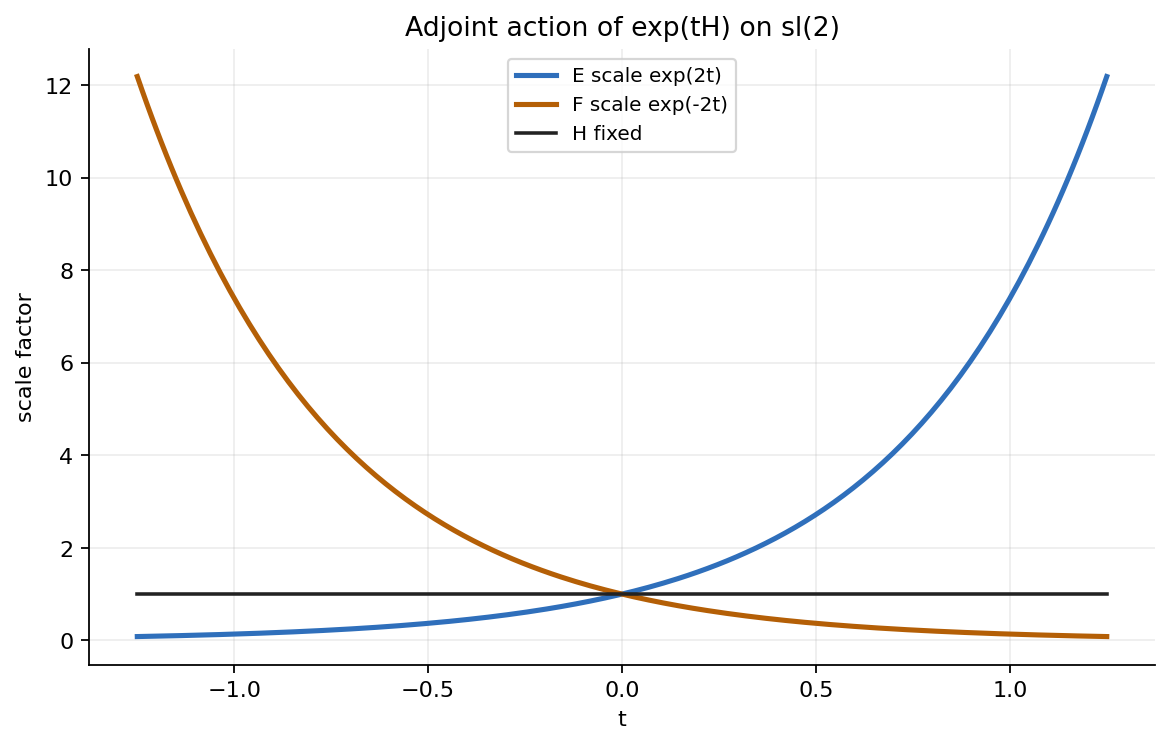

In [7]:
t = sp.symbols("t", real=True)
E = sp.Matrix([[0, 1], [0, 0]])
F = sp.Matrix([[0, 0], [1, 0]])
H = sp.Matrix([[1, 0], [0, -1]])
basis = [E, F, H]
basis_names = ["E", "F", "H"]

def coords_in_sl2(M: sp.Matrix) -> sp.Matrix:
    a, b, c = M[0, 0], M[0, 1], M[1, 0]
    return sp.Matrix([b, c, a])

def ad_matrix(X: sp.Matrix) -> sp.Matrix:
    cols = [coords_in_sl2(X * B - B * X) for B in basis]
    return sp.Matrix.hstack(*cols)

adH = ad_matrix(H)
g_t = sp.diag(sp.exp(t), sp.exp(-t))
Ad_cols = [coords_in_sl2(sp.simplify(g_t * B * g_t.inv())) for B in basis]
Ad_exp_tH = sp.simplify(sp.Matrix.hstack(*Ad_cols))
exp_ad_tH = sp.simplify((t * adH).exp())
adjoint_residual = sp.simplify(Ad_exp_tH - exp_ad_tH)

t_vals = np.linspace(-1.25, 1.25, 200)
scale_E = np.exp(2 * t_vals)
scale_F = np.exp(-2 * t_vals)
scale_H = np.ones_like(t_vals)

fig, ax = plt.subplots(figsize=(8.6, 5.0))
ax.plot(t_vals, scale_E, color="#2f6fbb", linewidth=2.3, label="E scale exp(2t)")
ax.plot(t_vals, scale_F, color="#b45f06", linewidth=2.3, label="F scale exp(-2t)")
ax.plot(t_vals, scale_H, color="#222222", linewidth=1.6, label="H fixed")
ax.set_title("Adjoint action of exp(tH) on sl(2)")
ax.set_xlabel("t")
ax.set_ylabel("scale factor")
ax.legend(fontsize=9)
adjoint_figure = record(save_matplotlib(fig, FIGURES / "sl2_adjoint_scaling.png"))
plt.close(fig)

adjoint_rows = [
    {"basis_vector": "E", "adH_eigenvalue": 2, "Ad_exp_tH_scale": "exp(2t)"},
    {"basis_vector": "F", "adH_eigenvalue": -2, "Ad_exp_tH_scale": "exp(-2t)"},
    {"basis_vector": "H", "adH_eigenvalue": 0, "Ad_exp_tH_scale": "1"},
]
adjoint_table = record(save_csv(adjoint_rows, TABLES / "sl2_adjoint_scaling.csv"))
adjoint_report = record(save_json({
    "adH_matrix_basis_EFH": [[str(entry) for entry in row] for row in adH.tolist()],
    "Ad_exp_tH_matrix_basis_EFH": [[str(entry) for entry in row] for row in Ad_exp_tH.tolist()],
    "residual_Ad_exp_equals_exp_ad": [[str(entry) for entry in row] for row in adjoint_residual.tolist()],
    "checks": {
        "Ad_exp_tH_equals_exp_t_adH": bool(all(sp.simplify(entry) == 0 for entry in adjoint_residual)),
    },
}, CHECKS / "sl2_adjoint_checks.json"))
chapter_checks["sl2_ad_exp_identity_holds"] = bool(all(sp.simplify(entry) == 0 for entry in adjoint_residual))
print(json.dumps({"figure": rel(adjoint_figure), "table": rel(adjoint_table), "checks": rel(adjoint_report)}, indent=2))
display_artifact(adjoint_figure)


## 6. Killing Form, Semisimplicity, and Compactness

The Killing form `B(X,Y)=Tr(ad X ad Y)` detects semisimplicity when it is nondegenerate. Over the real numbers, compact semisimple Lie algebras have negative definite Killing form. The noncompact algebra `sl(2,R)` is semisimple but has indefinite signature; its compact real form `su(2)` has negative definite signature.

The table computes the signatures from structure constants. This turns the chapter's compactness criterion into a reproducible finite-dimensional check.


{
  "figure": "artifacts/chapter-02-lie-groups-and-lie-algebras/figures/killing_form_signature_comparison.png",
  "table": "artifacts/chapter-02-lie-groups-and-lie-algebras/tables/killing_form_signature_comparison.csv",
  "checks": "artifacts/chapter-02-lie-groups-and-lie-algebras/checks/killing_form_signature_checks.json"
}


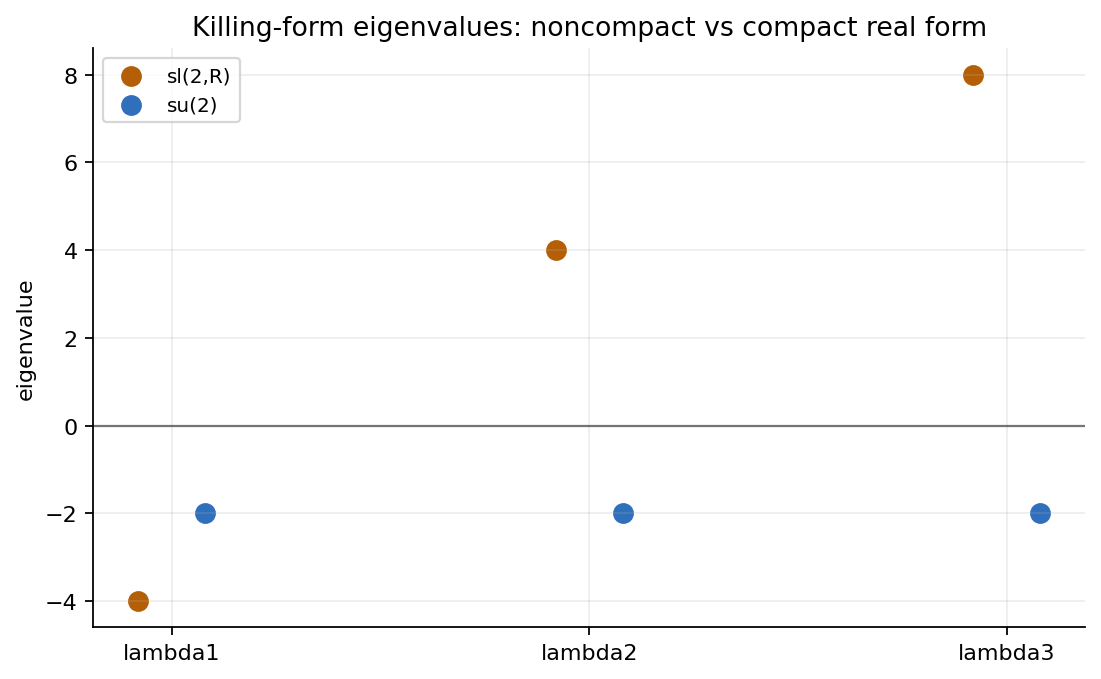

In [8]:
def killing_matrix_from_brackets(brackets: dict[tuple[int, int], dict[int, int]], dim: int) -> np.ndarray:
    ad_mats = []
    for i in range(dim):
        A = np.zeros((dim, dim), dtype=float)
        for j in range(dim):
            coeffs = brackets.get((i, j), {})
            for k, value in coeffs.items():
                A[k, j] = value
        ad_mats.append(A)
    K = np.zeros((dim, dim), dtype=float)
    for i in range(dim):
        for j in range(dim):
            K[i, j] = np.trace(ad_mats[i] @ ad_mats[j])
    return K

# sl2 basis E,F,H: [E,F]=H, [H,E]=2E, [H,F]=-2F.
sl2_brackets = {
    (0, 1): {2: 1}, (1, 0): {2: -1},
    (2, 0): {0: 2}, (0, 2): {0: -2},
    (2, 1): {1: -2}, (1, 2): {1: 2},
}

# su2-style basis with [e1,e2]=e3, [e2,e3]=e1, [e3,e1]=e2.
su2_brackets = {
    (0, 1): {2: 1}, (1, 0): {2: -1},
    (1, 2): {0: 1}, (2, 1): {0: -1},
    (2, 0): {1: 1}, (0, 2): {1: -1},
}

K_sl2 = killing_matrix_from_brackets(sl2_brackets, 3)
K_su2 = killing_matrix_from_brackets(su2_brackets, 3)
eig_sl2 = np.linalg.eigvalsh(K_sl2)
eig_su2 = np.linalg.eigvalsh(K_su2)

signature_rows = [
    {"lie_algebra": "sl(2,R)", "killing_matrix": str(K_sl2.tolist()), "eigenvalues": str([round(float(v), 6) for v in eig_sl2]), "signature": "indefinite", "compactness_signal": "not compact"},
    {"lie_algebra": "su(2) compact real form", "killing_matrix": str(K_su2.tolist()), "eigenvalues": str([round(float(v), 6) for v in eig_su2]), "signature": "negative definite", "compactness_signal": "compact semisimple"},
]
signature_table = record(save_csv(signature_rows, TABLES / "killing_form_signature_comparison.csv"))

fig, ax = plt.subplots(figsize=(8, 4.7))
positions = np.arange(3)
ax.scatter(positions - 0.08, eig_sl2, color="#b45f06", s=70, label="sl(2,R)")
ax.scatter(positions + 0.08, eig_su2, color="#2f6fbb", s=70, label="su(2)")
ax.axhline(0, color="#222222", linewidth=1.0, alpha=0.6)
ax.set_xticks(positions)
ax.set_xticklabels(["lambda1", "lambda2", "lambda3"])
ax.set_title("Killing-form eigenvalues: noncompact vs compact real form")
ax.set_ylabel("eigenvalue")
ax.legend(fontsize=9)
killing_figure = record(save_matplotlib(fig, FIGURES / "killing_form_signature_comparison.png"))
plt.close(fig)

killing_report = record(save_json({
    "sl2_eigenvalues": [float(v) for v in eig_sl2],
    "su2_eigenvalues": [float(v) for v in eig_su2],
    "checks": {
        "sl2_killing_form_is_nondegenerate": bool(np.min(np.abs(eig_sl2)) > 1e-12),
        "sl2_killing_form_is_indefinite": bool(np.any(eig_sl2 > 0) and np.any(eig_sl2 < 0)),
        "su2_killing_form_is_negative_definite": bool(np.all(eig_su2 < 0)),
    },
}, CHECKS / "killing_form_signature_checks.json"))
chapter_checks["sl2_killing_form_nondegenerate"] = bool(np.min(np.abs(eig_sl2)) > 1e-12)
chapter_checks["sl2_killing_form_indefinite"] = bool(np.any(eig_sl2 > 0) and np.any(eig_sl2 < 0))
chapter_checks["su2_killing_form_negative_definite"] = bool(np.all(eig_su2 < 0))
print(json.dumps({"figure": rel(killing_figure), "table": rel(signature_table), "checks": rel(killing_report)}, indent=2))
display_artifact(killing_figure)


## 7. Invariant Differential Forms and Maurer-Cartan Equations

The final technical section returns from algebra to differential forms. A left-invariant coframe on a Lie group records the structure constants through the Maurer-Cartan equations. For the Heisenberg group with coordinates `(x,y,z)` and multiplication arranged so that the central direction measures area swept by `x` and `y`, a standard left-invariant coframe is

`omega1 = dx`, `omega2 = dy`, `omega3 = dz - x dy`.

The computation checks `d omega1 = 0`, `d omega2 = 0`, and `d omega3 = - omega1 wedge omega2`. The plot shows the horizontal plane field `omega3=0` projected over the `(x,y)` plane.


{
  "figure": "artifacts/chapter-02-lie-groups-and-lie-algebras/figures/heisenberg_maurer_cartan_forms.png",
  "table": "artifacts/chapter-02-lie-groups-and-lie-algebras/tables/heisenberg_maurer_cartan_forms.csv",
  "checks": "artifacts/chapter-02-lie-groups-and-lie-algebras/checks/heisenberg_maurer_cartan_checks.json"
}


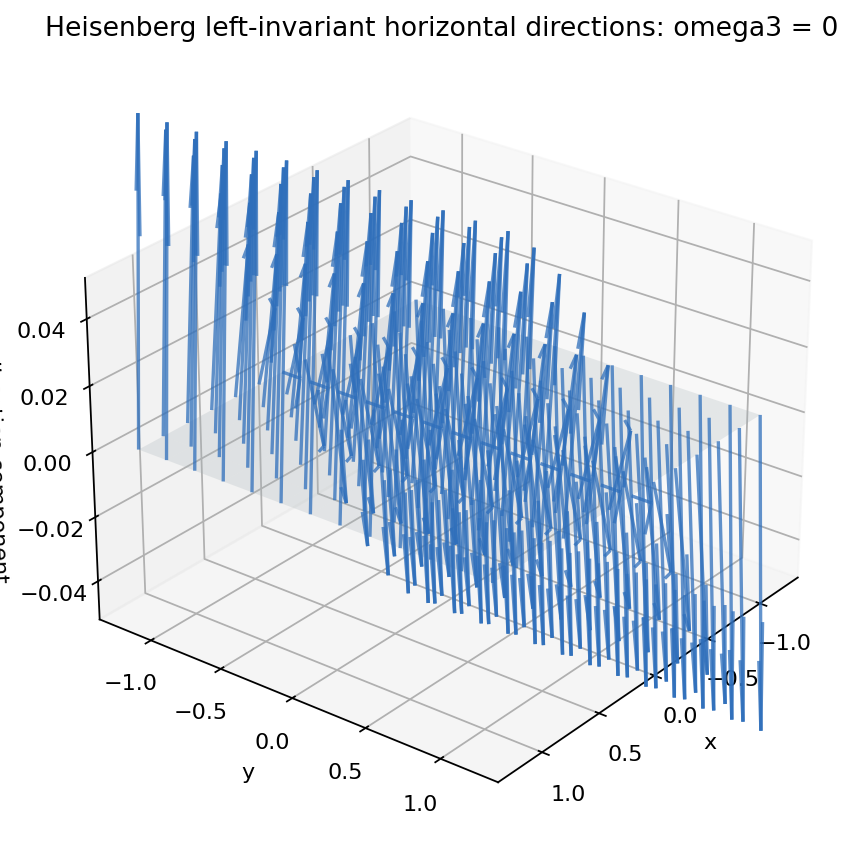

In [9]:
x_sym, y_sym, z_sym = sp.symbols("x y z")

def d_one_form_xyz(form: tuple[sp.Expr, sp.Expr, sp.Expr]) -> dict[tuple[str, str], sp.Expr]:
    coords3 = [x_sym, y_sym, z_sym]
    names = ["dx", "dy", "dz"]
    result = {}
    for i in range(3):
        for j in range(i + 1, 3):
            coeff = sp.simplify(sp.diff(form[j], coords3[i]) - sp.diff(form[i], coords3[j]))
            result[(names[i], names[j])] = coeff
    return result

omega1 = (sp.Integer(1), sp.Integer(0), sp.Integer(0))
omega2 = (sp.Integer(0), sp.Integer(1), sp.Integer(0))
omega3 = (sp.Integer(0), -x_sym, sp.Integer(1))
domega1 = d_one_form_xyz(omega1)
domega2 = d_one_form_xyz(omega2)
domega3 = d_one_form_xyz(omega3)

maurer_checks = {
    "domega1_zero": all(sp.simplify(v) == 0 for v in domega1.values()),
    "domega2_zero": all(sp.simplify(v) == 0 for v in domega2.values()),
    "domega3_equals_minus_omega1_wedge_omega2": bool(domega3[("dx", "dy")] == -1 and domega3[("dx", "dz")] == 0 and domega3[("dy", "dz")] == 0),
}

grid = np.linspace(-1.2, 1.2, 13)
Xg, Yg = np.meshgrid(grid, grid)
Ug = np.ones_like(Xg)
Vg = np.zeros_like(Yg)
Wg = Xg  # omega3(V)=dz(V)-x dy(V); vector d/dy + x d/dz is horizontal.

fig = plt.figure(figsize=(8.8, 6.4))
ax = fig.add_subplot(111, projection="3d")
ax.quiver(Xg, Yg, np.zeros_like(Xg), np.zeros_like(Xg), np.ones_like(Yg), Wg, length=0.13, normalize=True, color="#2f6fbb", alpha=0.75)
ax.plot_surface(Xg, Yg, np.zeros_like(Xg), color="#d9e7ef", alpha=0.25, linewidth=0)
ax.set_title("Heisenberg left-invariant horizontal directions: omega3 = 0")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z direction component")
ax.view_init(elev=27, azim=38)
mc_figure = record(save_matplotlib(fig, FIGURES / "heisenberg_maurer_cartan_forms.png"))
plt.close(fig)

mc_rows = [
    {"form": "omega1", "exterior_derivative": str(domega1), "Maurer_Cartan_role": "closed first horizontal form"},
    {"form": "omega2", "exterior_derivative": str(domega2), "Maurer_Cartan_role": "closed second horizontal form"},
    {"form": "omega3", "exterior_derivative": str(domega3), "Maurer_Cartan_role": "central bracket recorded as -omega1 wedge omega2"},
]
mc_table = record(save_csv(mc_rows, TABLES / "heisenberg_maurer_cartan_forms.csv"))
mc_report = record(save_json({
    "forms": {"omega1": "dx", "omega2": "dy", "omega3": "dz - x dy"},
    "domega": {"omega1": {str(k): str(v) for k, v in domega1.items()}, "omega2": {str(k): str(v) for k, v in domega2.items()}, "omega3": {str(k): str(v) for k, v in domega3.items()}},
    "checks": maurer_checks,
}, CHECKS / "heisenberg_maurer_cartan_checks.json"))
chapter_checks["heisenberg_maurer_cartan_equations_hold"] = bool(all(maurer_checks.values()))
print(json.dumps({"figure": rel(mc_figure), "table": rel(mc_table), "checks": rel(mc_report)}, indent=2))
display_artifact(mc_figure)


## Applied Lab: Exponential Behavior Is Local Before It Is Global

The chapter repeatedly distinguishes local statements from global ones. Near the identity, the exponential map gives canonical coordinates and the local group law is governed by the bracket. Globally, topology and closedness intervene: a torus winding may be injectively parametrized but not closed, and a noncompact group may have elements missed by the exponential map.

Use the lab pieces above as controlled experiments. Change the `SE(2)` generator, the torus slope, or the Lie algebra structure constants. Then rerun the checks and ask which conclusion is local, which is algebraic, and which depends on the global topology of the group.


## Final Sanity and Artifact Check

The final checks confirm that the visuals are tied to the chapter's main mechanisms: one-parameter subgroups, PBW rewriting, subgroup closure, coset orbit-stabilizer geometry, adjoint action, Killing-form compactness diagnostics, and Maurer-Cartan equations.


In [10]:
final_sanity = {
    "chapter": "Chapter II. Lie Groups and Lie Algebras",
    "source_span": "printed pages 98-154, approximately PDF pages 125-181",
    "artifact_count": len(artifact_paths),
    "artifacts": [rel(path) for path in artifact_paths],
    "checks": chapter_checks,
    "coverage_note": "Every major source block from exponential maps through invariant forms is represented by a visual, symbolic check, numerical experiment, or explicit coverage-ledger entry.",
}
failed = [name for name, value in chapter_checks.items() if isinstance(value, bool) and not value]
if failed:
    raise AssertionError(f"Chapter sanity checks failed: {failed}")
final_sanity_path = record(save_json(final_sanity, CHECKS / "final_sanity.json"))
assert_artifacts(artifact_paths, min_bytes=64)
assert_artifacts([final_sanity_path], min_bytes=64)
print(json.dumps({"final_sanity": rel(final_sanity_path), "boolean_checks": len([v for v in chapter_checks.values() if isinstance(v, bool)]), "failed": failed}, indent=2))
display_artifact(final_sanity_path)


{
  "final_sanity": "artifacts/chapter-02-lie-groups-and-lie-algebras/checks/final_sanity.json",
  "boolean_checks": 13,
  "failed": []
}


`final_sanity.json`

## Takeaways

Chapter II explains why Lie theory is both infinitesimal and global. The Lie algebra captures the bracket of left-invariant vector fields, controls the local group law near the identity, and determines one-parameter subgroups through the exponential map. The universal enveloping algebra packages bracket relations into associative normal forms, which later becomes essential for representation theory.

Subgroups and homogeneous spaces add topology back into the story. Every subalgebra integrates to a connected Lie subgroup, but the subgroup may fail to be closed in the ambient topology. Closed subgroups give honest coset manifolds, and transitive actions are read through orbit and isotropy. The adjoint action makes the group act on its own infinitesimal model, and semisimplicity is detected by the Killing form. Finally, invariant differential forms translate structure constants into Maurer-Cartan equations, making the bracket visible as exterior calculus on the group.
